# DDPM Visualizations (FashionMNIST)

This notebook creates the required plots and image grids for Tasks 0–2, plus generated sample visualizations from checkpoints.

In [1]:
from pathlib import Path
import sys
import torch
import csv
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, utils

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from diffusion.schedule import make_beta_schedule, compute_diffusion_buffers, extract
from diffusion.forward import q_sample
from diffusion.posterior import predict_x0_from_eps
from diffusion.ddpm import ancestral_sample, ddim_sample
from models.unet import SmallUNet
from torchsummary import summary
from dataset_metrics import compute_feature_stats, dataset_fid_from_stats, dataset_kid, extract_embeddings_from_tensor, load_or_compute_reference_stats, load_or_train_feature_extractor, sample_in_batches

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)

Device: mps


In [2]:
# Hyperparameters for the diffusion process

L = 1000
beta_min = 1e-4
beta_max = 2e-2

betas_linear = make_beta_schedule(L=L, schedule_type='linear', beta_min=beta_min, beta_max=beta_max, device=device)
betas_cosine = make_beta_schedule(L=L, schedule_type='cosine', beta_min=beta_min, beta_max=beta_max, device=device)

buf_linear = compute_diffusion_buffers(betas_linear)
buf_cosine = compute_diffusion_buffers(betas_cosine)

In [3]:
# Data preprocessing and scheduling

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2.0 - 1.0),
])
train_ds = datasets.FashionMNIST(root=str(ROOT / 'data'), train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=64, shuffle=True)

print('Dataset size:', len(train_ds))
print('x range target: [-1, 1]')

Dataset size: 60000
x range target: [-1, 1]


Actual tensor range: -1.0 1.0


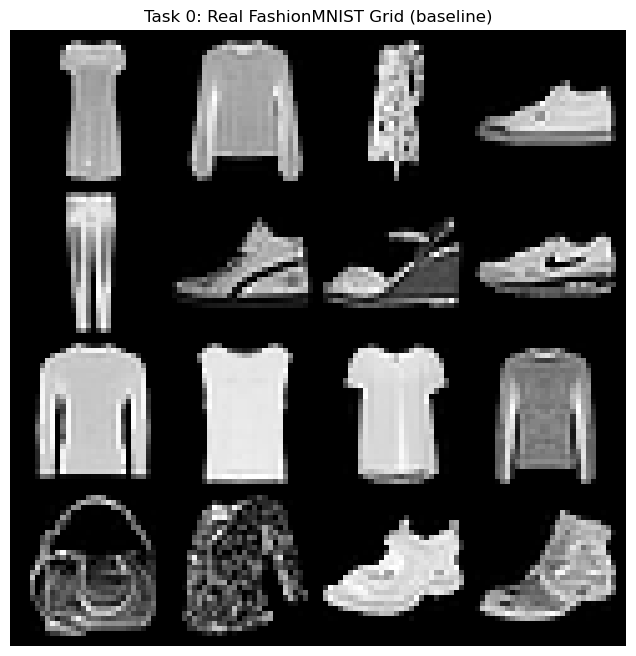

In [48]:
# Visualize a grid of real images from the dataset

x_real, y_real = next(iter(train_loader))
print('Actual tensor range:', float(x_real.min()), float(x_real.max()))

grid_real = utils.make_grid((x_real[:16] + 1) / 2, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid_real.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.title('Task 0: Real FashionMNIST Grid (baseline)')
plt.show()

## Forward Process

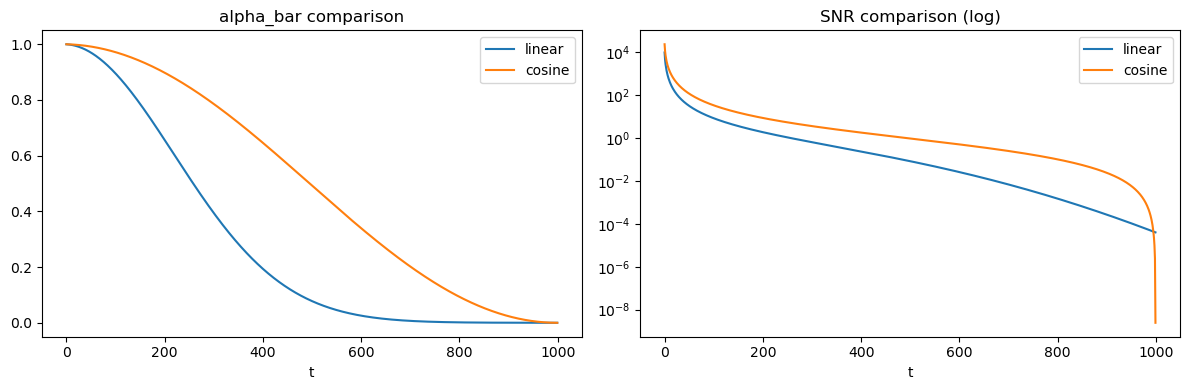

In [49]:
# Comparison of linear and cosine scheduler on alpha bar and SNR across timesteps (t)

ab_linear = buf_linear.alpha_bars.detach().cpu()
ab_cosine = buf_cosine.alpha_bars.detach().cpu()
snr_linear = ab_linear / (1 - ab_linear)
snr_cosine = ab_cosine / (1 - ab_cosine)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ab_linear.numpy(), label='linear')
ax[0].plot(ab_cosine.numpy(), label='cosine')
ax[0].set_title('alpha_bar comparison')
ax[0].set_xlabel('t')
ax[0].legend()

ax[1].plot(snr_linear.numpy(), label='linear')
ax[1].plot(snr_cosine.numpy(), label='cosine')
ax[1].set_yscale('log')
ax[1].set_title('SNR comparison (log)')
ax[1].set_xlabel('t')
ax[1].legend()

plt.tight_layout()
plt.show()

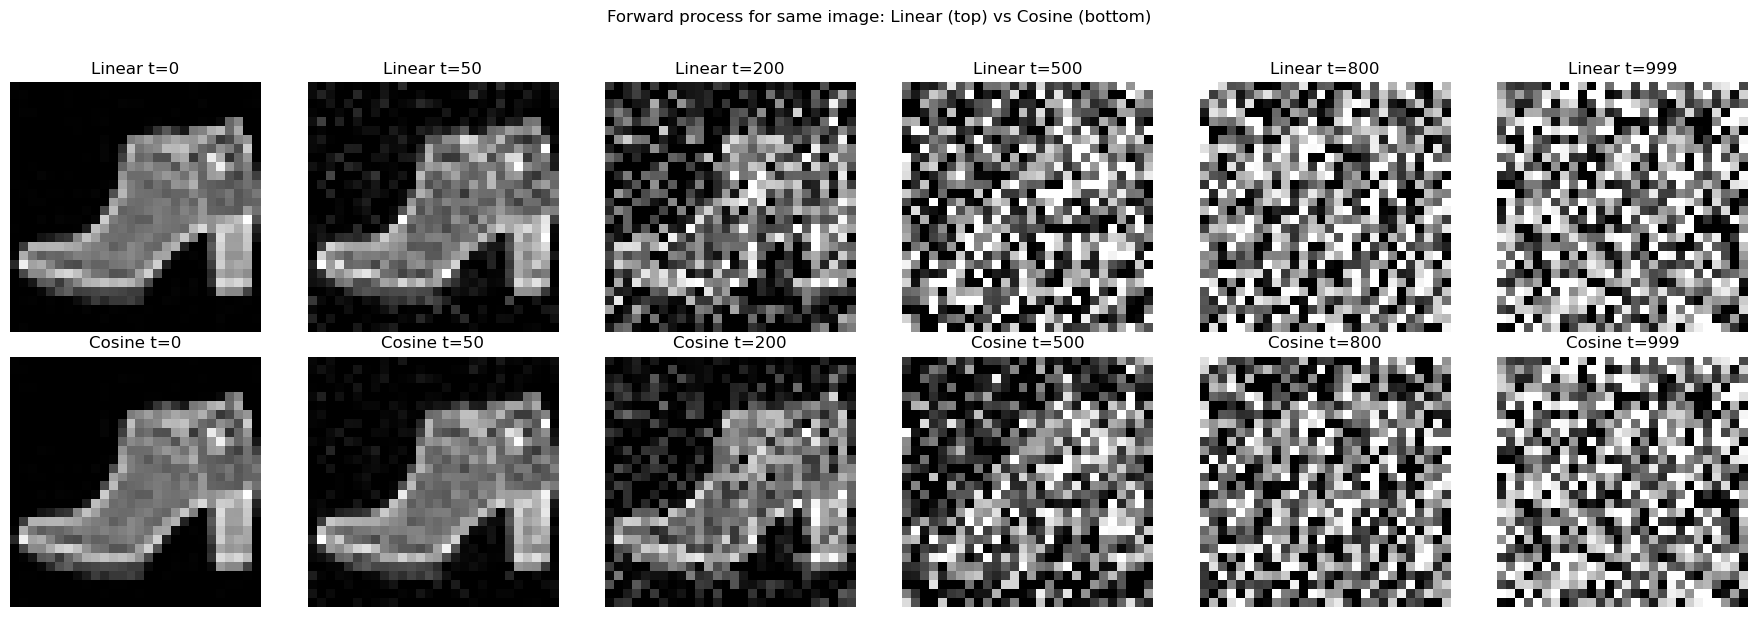

In [50]:
# Side-by-side forward noising: linear (top row) vs cosine (bottom row)

rand_idx = torch.randint(0, x_real.shape[0], (1,)).item()
x0_same = x_real[rand_idx:rand_idx + 1].to(device)
steps_compare = [0, 50, 200, 500, 800, 999]

gen = torch.Generator(device=device)
gen.manual_seed(123)
noise_bank = {s: torch.randn(x0_same.shape, device=device, generator=gen) for s in steps_compare}

fig, axes = plt.subplots(2, len(steps_compare), figsize=(3 * len(steps_compare), 6))
for j, s in enumerate(steps_compare):
    t_s = torch.full((1,), s, device=device, dtype=torch.long)
    eps_s = noise_bank[s]

    xt_linear = q_sample(x0=x0_same, t=t_s, buffers=buf_linear, eps=eps_s)
    xt_cosine = q_sample(x0=x0_same, t=t_s, buffers=buf_cosine, eps=eps_s)

    img_linear = ((xt_linear[0].detach().cpu() + 1) / 2).clamp(0, 1)
    img_cosine = ((xt_cosine[0].detach().cpu() + 1) / 2).clamp(0, 1)

    axes[0, j].imshow(img_linear.permute(1, 2, 0).squeeze(), cmap='gray')
    axes[0, j].set_title(f'Linear t={s}')
    axes[0, j].axis('off')

    axes[1, j].imshow(img_cosine.permute(1, 2, 0).squeeze(), cmap='gray')
    axes[1, j].set_title(f'Cosine t={s}')
    axes[1, j].axis('off')

plt.suptitle(f'Forward process for same image: Linear (top) vs Cosine (bottom)', y=1.02)
plt.tight_layout()
plt.show()

In [53]:
# Empirical verification of q(x_t|x_0): mean and variance for fixed x0 and t (linear scheduler)

x0_fix = x_real[0:1].to(device)
t_check = 500
num_samples = 2048

x0_rep = x0_fix.repeat(num_samples, 1, 1, 1)
t_rep = torch.full((num_samples,), t_check, device=device, dtype=torch.long)
eps = torch.randn_like(x0_rep)
xt_rep = q_sample(x0=x0_rep, t=t_rep, buffers=buf_linear, eps=eps)

emp_mean = xt_rep.mean(dim=0, keepdim=True)
emp_var_map = xt_rep.var(dim=0, unbiased=False, keepdim=True)

theory_mean = extract(buf_linear.sqrt_alpha_bars, torch.tensor([t_check], device=device), x0_fix.shape) * x0_fix
theory_var = float(buf_linear.one_minus_alpha_bars[t_check].item()) if hasattr(buf_linear, 'one_minus_alpha_bars') else float((1 - buf_linear.alpha_bars[t_check]).item())

mean_mse = float(((emp_mean - theory_mean) ** 2).mean().item())
var_avg_emp = float(emp_var_map.mean().item())
var_abs_err = abs(var_avg_emp - theory_var)

print(f't={t_check}, samples={num_samples}')
print(f'Mean MSE(empirical vs theoretical) = {mean_mse:.8f}')
print(f'Variance empirical avg = {var_avg_emp:.8f}')
print(f'Variance theoretical  = {theory_var:.8f}')
print(f'Variance absolute error = {var_abs_err:.8f}')

t=500, samples=2048
Mean MSE(empirical vs theoretical) = 0.00045263
Variance empirical avg = 0.92208898
Variance theoretical  = 0.92220336
Variance absolute error = 0.00011438


In [54]:
# Empirical verification of q(x_t|x_0): mean and variance for fixed x0 and t (cosine scheduler)

xt_rep = q_sample(x0=x0_rep, t=t_rep, buffers=buf_cosine, eps=eps)

emp_mean = xt_rep.mean(dim=0, keepdim=True)
emp_var_map = xt_rep.var(dim=0, unbiased=False, keepdim=True)

theory_mean = extract(buf_cosine.sqrt_alpha_bars, torch.tensor([t_check], device=device), x0_fix.shape) * x0_fix
theory_var = float(buf_cosine.one_minus_alpha_bars[t_check].item()) if hasattr(buf_cosine, 'one_minus_alpha_bars') else float((1 - buf_cosine.alpha_bars[t_check]).item())

mean_mse = float(((emp_mean - theory_mean) ** 2).mean().item())
var_avg_emp = float(emp_var_map.mean().item())
var_abs_err = abs(var_avg_emp - theory_var)

print(f't={t_check}, samples={num_samples}')
print(f'Mean MSE(empirical vs theoretical) = {mean_mse:.8f}')
print(f'Variance empirical avg = {var_avg_emp:.8f}')
print(f'Variance theoretical  = {theory_var:.8f}')
print(f'Variance absolute error = {var_abs_err:.8f}')

t=500, samples=2048
Mean MSE(empirical vs theoretical) = 0.00024919
Variance empirical avg = 0.50765198
Variance theoretical  = 0.50771493
Variance absolute error = 0.00006294


# Model

In [4]:
# U-Net parameter count and model summary (torchsummary)
model_for_summary = SmallUNet(
    in_channels=1,
    out_channels=1,
    channel_multipliers=(32, 64, 128),
    time_emb_dim=128,
).to("cpu")

# Parameter counts
total_params = sum(p.numel() for p in model_for_summary.parameters())
trainable_params = sum(p.numel() for p in model_for_summary.parameters() if p.requires_grad)
non_trainable_params = total_params - trainable_params

print(f"Total parameters:      {total_params:,}")
print(f"Trainable parameters:  {trainable_params:,}")
print(f"Non-trainable params:  {non_trainable_params:,}")

class UNetForSummary(torch.nn.Module):
    def __init__(self, base_model, timesteps):
        super().__init__()
        self.base_model = base_model
        self.timesteps = timesteps

    def forward(self, x):
        t = torch.zeros(x.shape[0], dtype=torch.long, device=x.device)
        t = torch.clamp(t, 0, self.timesteps - 1)
        return self.base_model(x, t)

wrapped = UNetForSummary(model_for_summary, L).to("cpu")
summary(wrapped, input_size=(1, 28, 28), device=str("cpu"))

Total parameters:      1,054,945
Trainable parameters:  1,054,945
Non-trainable params:  0
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 512]          66,048
              SiLU-2                  [-1, 512]               0
            Linear-3                  [-1, 128]          65,664
            Conv2d-4           [-1, 32, 28, 28]             320
         GroupNorm-5           [-1, 32, 28, 28]              64
              SiLU-6           [-1, 32, 28, 28]               0
            Conv2d-7           [-1, 32, 28, 28]           9,248
              SiLU-8                  [-1, 128]               0
            Linear-9                   [-1, 32]           4,128
        GroupNorm-10           [-1, 32, 28, 28]              64
             SiLU-11           [-1, 32, 28, 28]               0
           Conv2d-12           [-1, 32, 28, 28]           9,248
         Ide

# Training

In [41]:
# Optional: overlay training curves from matched-compute runs
import csv

def load_training_metrics(path):
    if not path.exists():
        return [], [], [], []
    steps, losses, grad_norms, param_norms = [], [], [], []
    with path.open('r', newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            steps.append(int(row['step']))
            losses.append(float(row['loss']))
            grad_norms.append(float(row.get('grad_norm', 0.0)))
            param_norms.append(float(row.get('param_norm', 0.0)))
    return steps, losses, grad_norms, param_norms

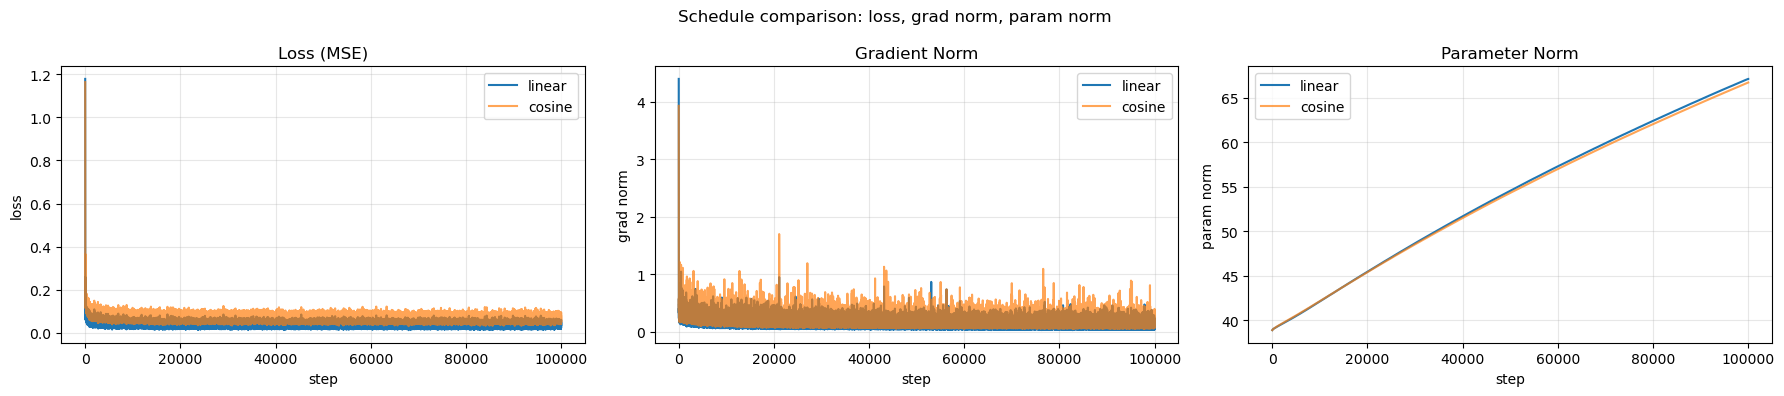

In [45]:
log_linear = ROOT / 'PA1' / 'outputs' / 'training' / 'linear_scheduler' / 'train_log.csv'
log_cosine = ROOT / 'PA1' / 'outputs' / 'training' / 'cosine_scheduler' / 'train_log.csv'

s_lin, l_lin, g_lin, p_lin = load_training_metrics(log_linear)
s_cos, l_cos, g_cos, p_cos = load_training_metrics(log_cosine)

fig, ax = plt.subplots(1, 3, figsize=(18, 4))

ax[0].plot(s_lin, l_lin, label='linear')
ax[0].plot(s_cos, l_cos, label='cosine', alpha=0.7)
ax[0].set_title('Loss (MSE)')
ax[0].set_xlabel('step')
ax[0].set_ylabel('loss')
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(s_lin, g_lin, label='linear')
ax[1].plot(s_cos, g_cos, label='cosine', alpha=0.7)
ax[1].set_title('Gradient Norm')
ax[1].set_xlabel('step')
ax[1].set_ylabel('grad norm')
ax[1].grid(alpha=0.3)
ax[1].legend()

ax[2].plot(s_lin, p_lin, label='linear')
ax[2].plot(s_cos, p_cos, label='cosine', alpha=0.7)
ax[2].set_title('Parameter Norm')
ax[2].set_xlabel('step')
ax[2].set_ylabel('param norm')
ax[2].grid(alpha=0.3)
ax[2].legend()

plt.suptitle('Schedule comparison: loss, grad norm, param norm')
plt.tight_layout()
plt.show()

# Reverse Process

In [9]:
ckpt_dir_linear = ROOT / 'PA1' / 'outputs' / 'training' / 'linear_scheduler'
ckpt_dir_cosine = ROOT / 'PA1' / 'outputs' / 'training' / 'cosine_scheduler'

ckpts_linear = sorted(ckpt_dir_linear.glob('ddpm_step_*.pt'))
ckpts_cosine = sorted(ckpt_dir_cosine.glob('ddpm_step_*.pt'))

def load_latest_checkpoint(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device)
    model = SmallUNet(in_channels=1, out_channels=1, channel_multipliers=(32, 64, 128), time_emb_dim=128).to(device)
    model.load_state_dict(ckpt['model'])
    model.eval()

    L_ckpt = int(ckpt.get('timesteps', L))
    schedule_type_ckpt = str(ckpt.get('schedule_type', 'linear'))
    beta_min_ckpt = float(ckpt.get('beta_min', beta_min))
    beta_max_ckpt = float(ckpt.get('beta_max', beta_max))

    betas_ckpt = make_beta_schedule(
        L=L_ckpt,
        schedule_type=schedule_type_ckpt,
        beta_min=beta_min_ckpt,
        beta_max=beta_max_ckpt,
        device=device,
    )
    buffers_ckpt = compute_diffusion_buffers(betas_ckpt)
    return model, buffers_ckpt, L_ckpt, schedule_type_ckpt

In [10]:
# Full ancestral sampling with latest checkpoints and side-by-side visualization

if not ckpts_linear or not ckpts_cosine:
    print('Missing checkpoint(s). Train both linear and cosine runs, then rerun this cell.')
else:
    ckpt_path_linear = ckpts_linear[-1]
    ckpt_path_cosine = ckpts_cosine[-1]
    print('Loading linear checkpoint:', ckpt_path_linear)
    print('Loading cosine checkpoint:', ckpt_path_cosine)

    model_linear, buffers_linear, L_linear, sched_linear = load_latest_checkpoint(ckpt_path_linear)
    model_cosine, buffers_cosine, L_cosine, sched_cosine = load_latest_checkpoint(ckpt_path_cosine)

    seed = 123
    samples_linear, _ = ancestral_sample(
        model=model_linear,
        buffers=buffers_linear,
        shape=(64, 1, 28, 28),
        device=device,
        capture_every=None,
        seed=seed,
    )
    samples_cosine, _ = ancestral_sample(
        model=model_cosine,
        buffers=buffers_cosine,
        shape=(64, 1, 28, 28),
        device=device,
        capture_every=None,
        seed=seed,
    )

Loading linear checkpoint: /Users/haiderdawood/Desktop/LUMS/Senior Year/Spring/DVLM/PA1/outputs/training/linear_scheduler/ddpm_step_0100000.pt
Loading cosine checkpoint: /Users/haiderdawood/Desktop/LUMS/Senior Year/Spring/DVLM/PA1/outputs/training/cosine_scheduler/ddpm_step_0100000.pt


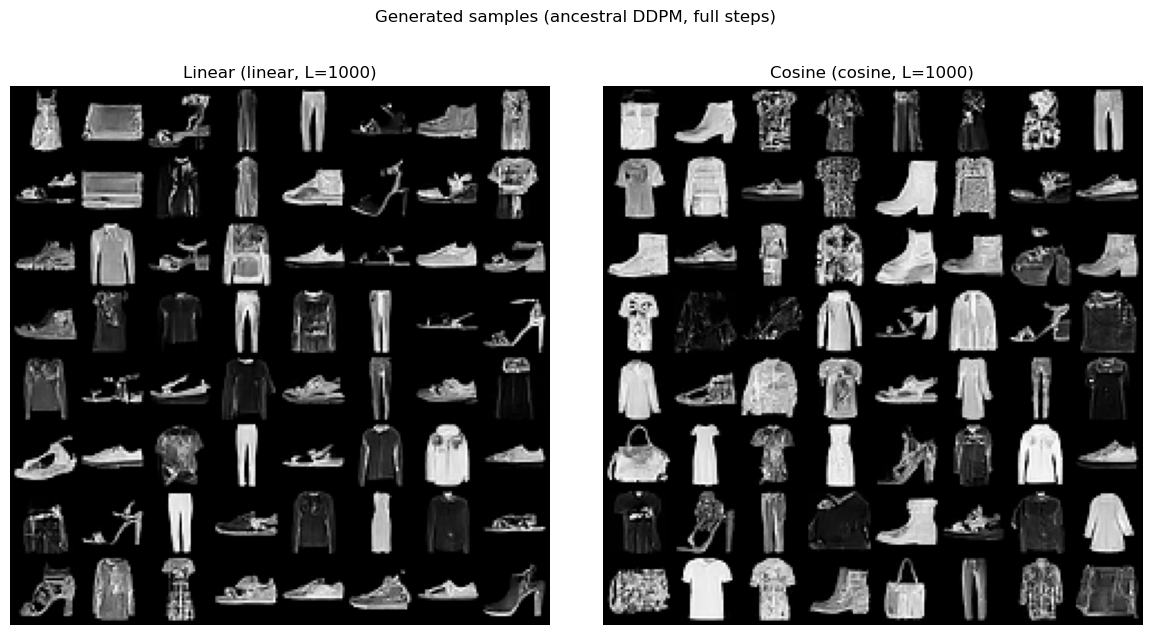

In [59]:
grid_linear = utils.make_grid(((samples_linear.detach().cpu() + 1) / 2).clamp(0, 1), nrow=8)
grid_cosine = utils.make_grid(((samples_cosine.detach().cpu() + 1) / 2).clamp(0, 1), nrow=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(grid_linear.permute(1, 2, 0).squeeze(), cmap='gray')
axes[0].axis('off')
axes[0].set_title(f'Linear ({sched_linear}, L={L_linear})')

axes[1].imshow(grid_cosine.permute(1, 2, 0).squeeze(), cmap='gray')
axes[1].axis('off')
axes[1].set_title(f'Cosine ({sched_cosine}, L={L_cosine})')

plt.suptitle('Generated samples (ancestral DDPM, full steps)', y=1.05)
plt.tight_layout()
plt.show()

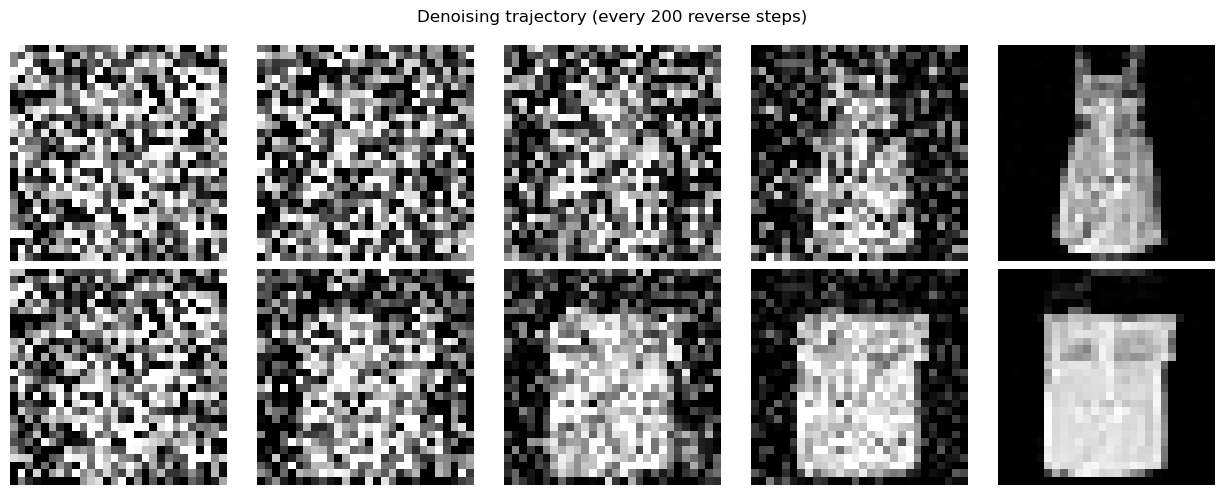

In [58]:
# Visualize denoising intermediates during ancestral sampling (linear vs cosine)

capture_every = 200

seed = 123
_, snapshots_linear = ancestral_sample(
    model=model_linear,
    buffers=buffers_linear,
    shape=(1, 1, 28, 28),
    device=device,
    capture_every=capture_every,
    seed=seed,
)
_, snapshots_cosine = ancestral_sample(
    model=model_cosine,
    buffers=buffers_cosine,
    shape=(1, 1, 28, 28),
    device=device,
    capture_every=capture_every,
    seed=seed,
)

if snapshots_linear and snapshots_cosine:
    imgs_linear = [((snap[0] + 1) / 2).clamp(0, 1).cpu() for snap in snapshots_linear]
    imgs_cosine = [((snap[0] + 1) / 2).clamp(0, 1).cpu() for snap in snapshots_cosine]

    n_cols = min(len(imgs_linear), len(imgs_cosine))
    imgs_linear = imgs_linear[:n_cols]
    imgs_cosine = imgs_cosine[:n_cols]

    fig, axes = plt.subplots(2, n_cols, figsize=(2.5 * n_cols, 5))
    for j in range(n_cols):
        axes[0, j].imshow(imgs_linear[j].permute(1, 2, 0).squeeze(), cmap='gray')
        axes[0, j].axis('off')
        if j == 0:
            axes[0, j].set_ylabel('Linear', rotation=0, labelpad=30)

        axes[1, j].imshow(imgs_cosine[j].permute(1, 2, 0).squeeze(), cmap='gray')
        axes[1, j].axis('off')
        if j == 0:
            axes[1, j].set_ylabel('Cosine', rotation=0, labelpad=30)

    plt.suptitle(f'Denoising trajectory (every {capture_every} reverse steps)')
    plt.tight_layout()
    plt.show()

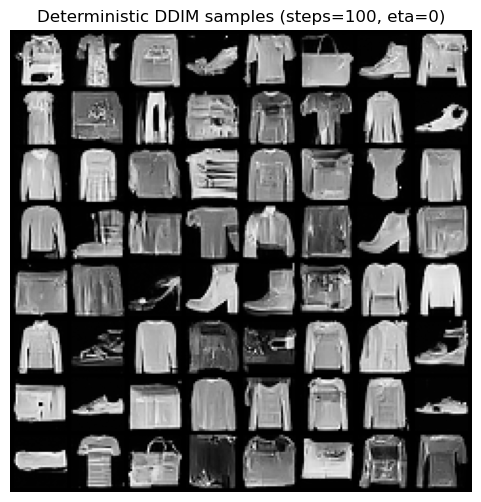

DDIM internal timesteps used: [999, 989, 979, 969, 959, 949, 938, 928, 918, 908] ...
Total DDIM timesteps: 100


In [ ]:
# Deterministic DDIM sampling (eta=0) with step reduction

num_ddim_steps = 100
num_ddim_steps = min(max(2, num_ddim_steps), L)

# Deterministic: same seed + eta=0 => same outputs across reruns
samples_ddim, _, ts_ddim = ddim_sample(
    model=model_linear,
    buffers=buffers_linear,
    shape=(64, 1, 28, 28),
    device=device,
    num_steps=num_ddim_steps,
    eta=0.0,
    seed=123,
)

grid_ddim = utils.make_grid(((samples_ddim.detach().cpu() + 1) / 2).clamp(0, 1), nrow=8)
plt.figure(figsize=(6, 6))
plt.imshow(grid_ddim.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.title(f'Deterministic DDIM samples (steps={num_ddim_steps}, eta=0)')
plt.show()

print('DDIM internal timesteps used:', ts_ddim.tolist()[:10], '...')
print('Total DDIM timesteps:', len(ts_ddim))

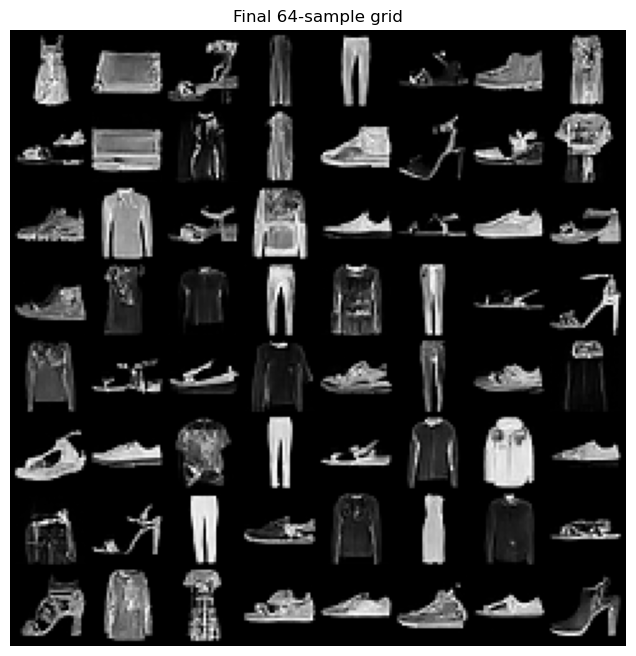

In [61]:
# Final 64-sample grid and fixed-seed denoising trajectory

final_64, _ = ancestral_sample(
    model=model_linear,
    buffers=buffers_linear,
    shape=(64, 1, 28, 28),
    device=device,
    seed=123,
)
grid_final = utils.make_grid(((final_64.detach().cpu() + 1) / 2).clamp(0, 1), nrow=8)
plt.figure(figsize=(8, 8))
plt.imshow(grid_final.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.title('Final 64-sample grid')
plt.show()

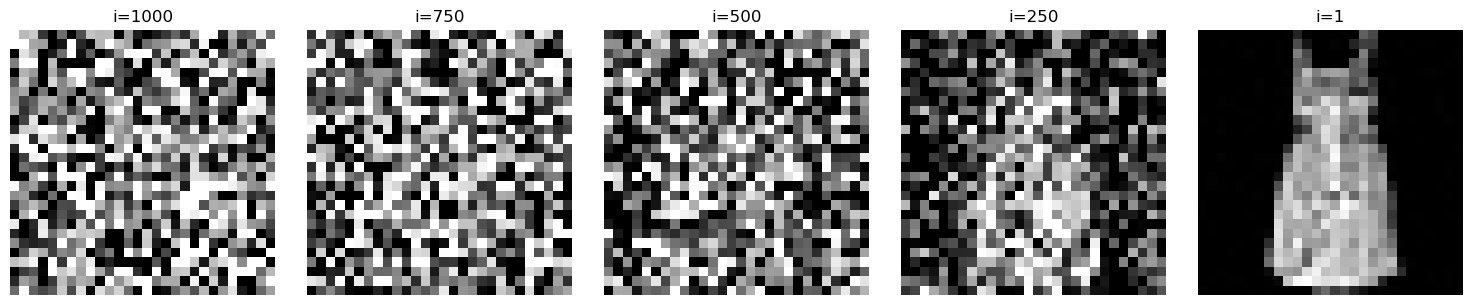

In [62]:
# Fixed-seed denoising trajectory

labels = [L, max(1, (3 * L) // 4), max(1, L // 2), max(1, L // 4), 1]
capture_steps = []
for lab in labels:
    if lab >= L:
        capture_steps.append(L)
    elif lab <= 1:
        capture_steps.append(0)
    else:
        capture_steps.append(lab - 1)

_, traj = ancestral_sample(
    model= model_linear,
    buffers=buffers_linear,
    shape=(1, 1, 28, 28),
    device=device,
    capture_steps=capture_steps,
    seed=123,
)

fig, axes = plt.subplots(1, len(traj), figsize=(3 * len(traj), 3))
if len(traj) == 1:
    axes = [axes]
for idx in range(len(traj)):
    img = ((traj[idx][0:1] + 1) / 2).clamp(0, 1)
    axes[idx].imshow(img[0].permute(1, 2, 0).squeeze(), cmap='gray')
    axes[idx].set_title(f'i={labels[idx]}')
    axes[idx].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Dataset-Specific Quantitative Metrics (FID, KID) setup and hyperparameters

metrics_dir = ROOT / 'PA1' / 'outputs' / 'metrics'
metrics_dir.mkdir(parents=True, exist_ok=True)

feature_extractor_path = metrics_dir / 'fashionmnist_feature_extractor.pt'
reference_stats_path = metrics_dir / 'fashionmnist_test_features.pt'

feature_epochs = 8
feature_train_batch_size = 256
feature_eval_batch_size = 512
metric_num_generated = 10_000
metric_sample_batch_size = 128
metric_seed = 123
kid_subset_size = 1_000
kid_num_subsets = 50


In [14]:
feature_cache_exists = feature_extractor_path.exists()
feature_model, feature_metadata = load_or_train_feature_extractor(
    cache_path=feature_extractor_path,
    data_root=ROOT / 'data',
    device=device,
    epochs=feature_epochs,
    train_batch_size=feature_train_batch_size,
    eval_batch_size=feature_eval_batch_size,
)
reference_cache_exists = reference_stats_path.exists()
reference_stats = load_or_compute_reference_stats(
    cache_path=reference_stats_path,
    model=feature_model,
    data_root=ROOT / 'data',
    device=device,
    eval_batch_size=feature_eval_batch_size,
)

print('Feature extractor:', 'loaded' if feature_cache_exists else 'trained and cached', feature_extractor_path)
print('Feature extractor test accuracy:', f"{feature_metadata.get('final_test_acc', float('nan')):.4f}")
print('Reference features:', 'loaded' if reference_cache_exists else 'computed and cached', reference_stats_path)
print('Reference sample count:', reference_stats['num_samples'])

Feature extractor: loaded /Users/haiderdawood/Desktop/LUMS/Senior Year/Spring/DVLM/PA1/outputs/metrics/fashionmnist_feature_extractor.pt
Feature extractor test accuracy: 0.8248
Reference features: loaded /Users/haiderdawood/Desktop/LUMS/Senior Year/Spring/DVLM/PA1/outputs/metrics/fashionmnist_test_features.pt
Reference sample count: 10000


In [15]:
def evaluate_dataset_metrics_for_checkpoint(label, ckpt_path, seed):
    metric_model, metric_buffers, metric_L, metric_schedule = load_latest_checkpoint(ckpt_path)
    print(f'[{label}] sampling {metric_num_generated} images from {ckpt_path.name} ...')
    generated = sample_in_batches(
        total_samples=metric_num_generated,
        batch_size=metric_sample_batch_size,
        seed=seed,
        show_progress=True,
        progress_desc=f'{label}: ancestral batches',
        sampler=lambda current_batch, batch_seed: ancestral_sample(
            model=metric_model,
            buffers=metric_buffers,
            shape=(current_batch, 1, 28, 28),
            device=device,
            seed=batch_seed,
        )[0],
    )
    generated_features = extract_embeddings_from_tensor(
        feature_model,
        generated,
        device=device,
        batch_size=feature_eval_batch_size,
    ) 
    gen_mean, gen_cov = compute_feature_stats(generated_features)
    kid_stats = dataset_kid(
        reference_stats['features'],
        generated_features,
        subset_size=kid_subset_size,
        num_subsets=kid_num_subsets,
        seed=seed,
    )
    return {
        'label': label,
        'checkpoint': str(ckpt_path),
        'schedule': metric_schedule,
        'timesteps': metric_L,
        'num_generated': int(generated.shape[0]),
        'dataset_fid': dataset_fid_from_stats(reference_stats['mean'], reference_stats['cov'], gen_mean, gen_cov),
        'dataset_kid': kid_stats['mean'],
        'dataset_kid_std': kid_stats['std'],
        'kid_subset_size': kid_stats['subset_size'],
        'kid_num_subsets': kid_stats['num_subsets'],
    }


In [16]:
dataset_metric_results = evaluate_dataset_metrics_for_checkpoint('linear', ckpts_linear[-1], seed=metric_seed)  
metrics_out_path = metrics_dir / 'dataset_metrics_latest.pt'
torch.save(dataset_metric_results, metrics_out_path)

print('\nDataset-specific quantitative metrics (FashionMNIST feature space)')
print(
    f"{dataset_metric_results['label']:>6} | samples={dataset_metric_results['num_generated']:5d} | "
    f"Dataset-FID={dataset_metric_results['dataset_fid']:.4f} | "
    f"Dataset-KID={dataset_metric_results['dataset_kid']:.6f} ± {dataset_metric_results['dataset_kid_std']:.6f} | "
    f"subset={dataset_metric_results['kid_subset_size']} x {dataset_metric_results['kid_num_subsets']}"
)
print('Saved metric payload to', metrics_out_path)

[linear] sampling 10000 images from ddpm_step_0100000.pt ...


linear: ancestral batches:   0%|          | 0/79 [00:00<?, ?it/s]


Dataset-specific quantitative metrics (FashionMNIST feature space)
linear | samples=10000 | Dataset-FID=31.9747 | Dataset-KID=31.546013 ± 3.747882 | subset=1000 x 50
Saved metric payload to /Users/haiderdawood/Desktop/LUMS/Senior Year/Spring/DVLM/PA1/outputs/metrics/dataset_metrics_latest.pt


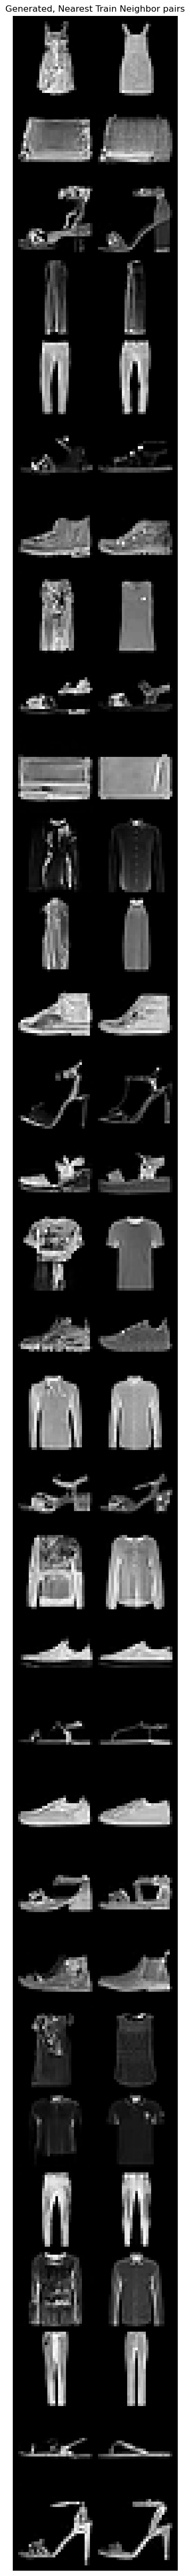

In [64]:
# Overfitting / memorization diagnostic: nearest neighbors in pixel space

nn_k = 32
gen = final_64[:nn_k].detach().cpu()

# Build train tensor in [-1, 1]
train_tensor = torch.stack([train_ds[i][0] for i in range(len(train_ds))], dim=0)

gen_flat = gen.view(gen.shape[0], -1).float()
train_flat = train_tensor.view(train_tensor.shape[0], -1).float()

best_dist = torch.full((gen_flat.shape[0],), float('inf'))
best_idx = torch.zeros((gen_flat.shape[0],), dtype=torch.long)

chunk_size = 2048
for start in range(0, train_flat.shape[0], chunk_size):
    end = min(start + chunk_size, train_flat.shape[0])
    d = torch.cdist(gen_flat, train_flat[start:end], p=2)
    vals, idx = torch.min(d, dim=1)
    improved = vals < best_dist
    best_dist[improved] = vals[improved]
    best_idx[improved] = idx[improved] + start

paired = []
for i in range(nn_k):
    paired.append(gen[i])
    paired.append(train_tensor[best_idx[i]])

pair_grid = utils.make_grid(((torch.stack(paired, dim=0) + 1) / 2).clamp(0, 1), nrow=2)
plt.figure(figsize=(4, 2 * nn_k))
plt.imshow(pair_grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.title('Generated, Nearest Train Neighbor pairs')
plt.show()
